In [1]:
#=========================================================
# explore_dharma.py
# Author: McKenna W. Stanford
# Date Created: 03/04/2023
# Utility: Explores output from dharma 3d runs.
#=========================================================

In [1]:
#=======================================
# Imports
#=======================================
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray
import datetime
import calendar
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import matplotlib
import pickle
import pandas as pd
import os
import numpy as np
from scipy import ndimage
from scipy.ndimage import gaussian_filter
from scipy.interpolate import NearestNDInterpolator as nn
from matplotlib.patches import Rectangle
from matplotlib import cm
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from matplotlib.lines import Line2D

In [2]:
#=======================================
# Diagnostics Parameters
#=======================================
space = '    '
#=======================================
# Functions
#=======================================
def print_diag(key,var):
    print(key)
    print(space,'Shape:',np.shape(var))
    print(space,'Max:',np.max(var))
    print(space,'Min:',np.min(var))
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx],idx

In [3]:
#sim_name = 'cntl_bulk_ice_ABIFM'
#sim_name = 'sip_bulk_ice_ABIFM'
#sim_name = 'sip_10x_bulk_ice_ABIFM'

sim_name = 'cntl_bulk_ice_ABIFM_hm'
#sim_name = 'sip_bulk_ice_ABIFM_hm'
#sim_name = 'sip_10x_bulk_ice_ABIFM_hm'

if sim_name == 'cntl_bulk_ice_ABIFM':
    suptitle = 'CNTL Bulk ABIFM'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/restart/'.format(sim_name)
    paths       = [path1,path2]

if sim_name == 'cntl_bulk_ice_ABIFM_hm':
    suptitle = 'CNTL Bulk ABIFM HM'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bulk_ice_ABIFM/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    paths       = [path1,path2]

if sim_name == 'sip_bulk_ice_ABIFM':
    suptitle = 'SIP Bulk ABIFM'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bulk_ice_ABIFM/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    paths       = [path1,path2]

if sim_name == 'sip_bulk_ice_ABIFM_hm':
    suptitle = 'SIP Bulk ABIFM HM'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bulk_ice_ABIFM/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    paths       = [path1,path2]

if sim_name == 'sip_10x_bulk_ice_ABIFM':
    suptitle = 'SIP 10X Bulk ABIFM'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bulk_ice_ABIFM/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    paths       = [path1,path2]

if sim_name == 'sip_10x_bulk_ice_ABIFM_hm':
    suptitle = 'SIP 10X Bulk ABIFM HM'
    path1 = '/pscratch/sd/m/mckenna/dharma_output/cntl_bulk_ice_ABIFM/'
    path2 = '/pscratch/sd/m/mckenna/dharma_output/{}/'.format(sim_name)
    paths       = [path1,path2]

In [4]:
iwrite = True

def load_path_data_bulk(path):
    """Load sounding and scalar data from a single DHARMA bulk-ice output path."""
    ncfile        = xarray.open_dataset(path + 'dharma.soundings.cdf')
    ncfile_scalar = xarray.open_dataset(path + 'dharma.scalars.cdf')
    rhobar = ncfile['rhobar'].values

    data = {
        'time':       ncfile['time'].values,
        'na_1':       ncfile['na_1'].values * rhobar / 1.e6,
        'na_2':       ncfile['na_2'].values * rhobar / 1.e6,
        'na_3':       ncfile['na_3'].values * rhobar / 1.e6,
        'nc_cld':     ncfile['nc_cld'].values,
        'nr_cld':     ncfile['nr_cld'].values,
        'clwc':       ncfile['qc'].values * rhobar * 1.e3,
        'rwc':        ncfile['qr'].values * rhobar * 1.e3,
        'lwc':        ncfile['ql'].values * rhobar * 1.e3,
        'qi_iwc':     ncfile['qi'].values  * rhobar * 1.e3,
        'qif_iwc':    ncfile['qif'].values * rhobar * 1.e3,
        'qid_iwc':    ncfile['qid'].values * rhobar * 1.e3,
        'qic_iwc':    ncfile['qic'].values * rhobar * 1.e3,
        'nif':        ncfile['nif'].values * rhobar / 1.e6,
        'nid':        ncfile['nid'].values * rhobar / 1.e6,
        'nic':        ncfile['nic'].values * rhobar / 1.e6,
        'nqif':       ncfile['nqif'].values,
        'nqid':       ncfile['nqid'].values,
        'nqic':       ncfile['nqic'].values,
        #'nqitot':    ncfile['nqitot'].values,
        'nqc':       ncfile['nqc'].values,
        'nqr':       ncfile['nqr'].values,
        'nif_cld':    ncfile['nif_cld'].values,
        'nid_cld':    ncfile['nid_cld'].values,
        'nic_cld':    ncfile['nic_cld'].values,
        'reff_icef':  ncfile['reff_icef'].values,
        'reff_iced':  ncfile['reff_iced'].values,
        'reff_icec':  ncfile['reff_icec'].values,
        'u':          ncfile['u'].values,
        'v':          ncfile['v'].values,
        'T':          ncfile['T'].values,
        'wmax':       ncfile['wmax'].values,
        'rhmax':      ncfile['RH_max'].values,
        'rhimax':     ncfile['RHI_max'].values,
        'opd_cloud':  ncfile['opd_cloud'].values,
        'reff_cloud': ncfile['reff_cloud'].values,
        'opd_rain':   ncfile['opd_rain'].values,
        'reff_rain':  ncfile['reff_rain'].values,
        'net_cond':   ncfile['net_cond'].values,
        'net_dep':    ncfile['net_dep'].values,
        'tke_smag':   ncfile['tke_smag'].values,
        'avg_T_flx':  ncfile_scalar['avg_T_flx'].values,
        'avg_qv_flx': ncfile_scalar['avg_qv_flx'].values,
        'avg_T_sfc':  ncfile_scalar['avg_T_sfc'].values,
        'avg_ustar':  ncfile_scalar['avg_ustar'].values,
        'rwp':        ncfile_scalar['rwp'].values,
        'clwp':       ncfile_scalar['cwp'].values,
        'lwp':        ncfile_scalar['lwp'].values,
        'iwp':        ncfile_scalar['iwp'].values,
        'iwpf':       ncfile_scalar['iwpf'].values,
        'iwpd':       ncfile_scalar['iwpc'].values,
        'iwpc':       ncfile_scalar['iwpd'].values,
        'max_w':      ncfile_scalar['max_w'].values,
        'max_sh_coag':  ncfile_scalar['max_sh_coag'].values,
        #'max_sh_coag_raw':  ncfile_scalar['max_sh_coag_raw'].values,
        'max_sh_in_c':  ncfile_scalar['max_sh_in_c'].values,
        'max_sh_in_r':  ncfile_scalar['max_sh_in_r'].values,
        'max_in_imm_c': ncfile_scalar['max_in_imm_c'].values,
        'max_in_imm_r': ncfile_scalar['max_in_imm_r'].values,
        'avg_precip': ncfile_scalar['avg_precip'].values,
        'max_precip': ncfile_scalar['max_precip'].values
    }

    # *** THE KEY MODIFICATION IS HERE ***
    # Check if 'max_sh_coag_raw' exists. If not, create a dummy version.
    if 'max_sh_coag_raw' in ncfile_scalar.variables:
        # If it exists, load it normally.
        data['max_sh_coag_raw'] = ncfile_scalar['max_sh_coag_raw'].values
    else:
        # If it doesn't exist, create a placeholder.
        print("    -> 'max_sh_coag_raw' not found. Creating a padded array.")
        # We mimic the shape and type of 'max_sh_coag', filling it with zeros or NaNs.
        # Using np.zeros_like is a robust way to do this.
        # This ensures it has the same length as the time dimension for this segment.
        data['max_sh_coag_raw'] = np.zeros_like(data['max_sh_coag'])
        # Alternatively, you could fill with NaNs if that's more appropriate for your analysis:
        # data['max_sh_coag_raw'] = np.full_like(data['max_sh_coag'], np.nan)
    
    # Check if 'max_sh_coag_raw' exists. If not, create a dummy version.
    if 'nqitot' in ncfile.variables:
        # If it exists, load it normally.
        data['nqitot'] = ncfile['nqitot'].values
    else:
        # If it doesn't exist, create a placeholder.
        print("    -> 'nqitot' not found. Creating a padded array.")
        # We mimic the shape and type of 'max_sh_coag', filling it with zeros or NaNs.
        # Using np.zeros_like is a robust way to do this.
        # This ensures it has the same length as the time dimension for this segment.
        data['nqitot'] = np.zeros_like(data['nqic'])
        # Alternatively, you could fill with NaNs if that's more appropriate for your analysis:
        # data['max_sh_coag_raw'] = np.full_like(data['max_sh_coag'], np.nan)
    


    return data, ncfile


# Load and stitch restart segments.
# The restart segment takes precedence: trim the previous segment to stop just
# before the restart's first time step, then append the restart segment.
segments = []
for path in paths:
    print(path)
    d, ncfile_last = load_path_data_bulk(path)
    if segments:
        restart_start = d['time'][0]
        prev = segments[-1]
        mask = prev['time'] < restart_start
        segments[-1] = {k: v[mask] for k, v in prev.items()}
    segments.append(d)

# Concatenate all segments.
# For ABIFM-only fields, pad the front of earlier (non-ABIFM) segments with zeros.
all_keys = set().union(*[seg.keys() for seg in segments])

out_dict = {}
for k in all_keys:
    arrays = []
    for seg in segments:
        if k in seg:
            arrays.append(seg[k])
    out_dict[k] = np.concatenate(arrays)

# Static grid variables from the last loaded file
out_dict['zt'] = ncfile_last['zt']
out_dict['zw'] = ncfile_last['zw']

#==========================================
# Unpack for use in downstream cells
#==========================================
time       = out_dict['time']
zw         = out_dict['zw'] * 1.e-3
zt         = out_dict['zt'] * 1.e-3
na_1       = out_dict['na_1']
na_2       = out_dict['na_2']
na_3       = out_dict['na_3']
na_tot     = na_1 + na_2 + na_3
nc_cld     = out_dict['nc_cld']
nr_cld     = out_dict['nr_cld']
clwc       = out_dict['clwc']
rwc        = out_dict['rwc']
lwc        = out_dict['lwc']
qi_iwc     = out_dict['qi_iwc']
qif_iwc    = out_dict['qif_iwc']
qid_iwc    = out_dict['qid_iwc']
qic_iwc    = out_dict['qic_iwc']
nif        = out_dict['nif']
nid        = out_dict['nid']
nic        = out_dict['nic']
nqif       = out_dict['nqif']
nqid       = out_dict['nqid']
nqic       = out_dict['nqic']
nqitot       = out_dict['nqitot']
nif_cld    = out_dict['nif_cld']
nid_cld    = out_dict['nid_cld']
nic_cld    = out_dict['nic_cld']
reff_icef  = out_dict['reff_icef']
reff_iced  = out_dict['reff_iced']
reff_icec  = out_dict['reff_icec']
u          = out_dict['u']
v          = out_dict['v']
T          = out_dict['T']
wind_speed = np.sqrt(u**2. + v**2.)
wmax       = out_dict['wmax']
rhmax      = out_dict['rhmax']
rhimax     = out_dict['rhimax']
opd_cloud  = out_dict['opd_cloud']
reff_cloud = out_dict['reff_cloud']
opd_rain   = out_dict['opd_rain']
reff_rain  = out_dict['reff_rain']
net_cond   = out_dict['net_cond']
net_dep    = out_dict['net_dep']
tke_smag   = out_dict['tke_smag']
avg_T_flx  = out_dict['avg_T_flx']
avg_qv_flx = out_dict['avg_qv_flx']
avg_T_sfc  = out_dict['avg_T_sfc']
avg_ustar  = out_dict['avg_ustar']
rwp        = out_dict['rwp']
clwp       = out_dict['clwp']
lwp        = out_dict['lwp']
iwp        = out_dict['iwp']
iwpf       = out_dict['iwpf']
iwpd       = out_dict['iwpd']
iwpc       = out_dict['iwpc']
max_w      = out_dict['max_w']
max_sh_coag = out_dict['max_sh_coag']
max_sh_coag_raw = out_dict['max_sh_coag_raw']
max_sh_in_c = out_dict['max_sh_in_c']
max_sh_in_r = out_dict['max_sh_in_r']
max_in_imm_c = out_dict['max_in_imm_c']
max_in_imm_r = out_dict['max_in_imm_r']


tmp_time = time / 3600.0  # hours

out_dict['wind_speed'] = wind_speed
out_dict['na_tot']     = na_tot
out_dict['tmp_time']   = tmp_time

if iwrite:
    save_path = '/pscratch/sd/m/mckenna/dharma_post/'
    file_name = f'{sim_name}_sounding_time_series.pkl'
    #print(out_dict.keys())
    with open(save_path + file_name, "wb") as f:
        pickle.dump(out_dict, f)

print('done')

/pscratch/sd/m/mckenna/dharma_output/cntl_bulk_ice_ABIFM/


/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


    -> 'max_sh_coag_raw' not found. Creating a padded array.
    -> 'nqitot' not found. Creating a padded array.
/pscratch/sd/m/mckenna/dharma_output/cntl_bulk_ice_ABIFM_hm/
done


/tmp/ipykernel_2286449/646275853.py:17: UserWarning: Log scale: values of z <= 0 have been masked
  mappable = ax.contourf(tmp_time, z, data.T, levels=levels, cmap=cmap, norm=norm, extend=extend)


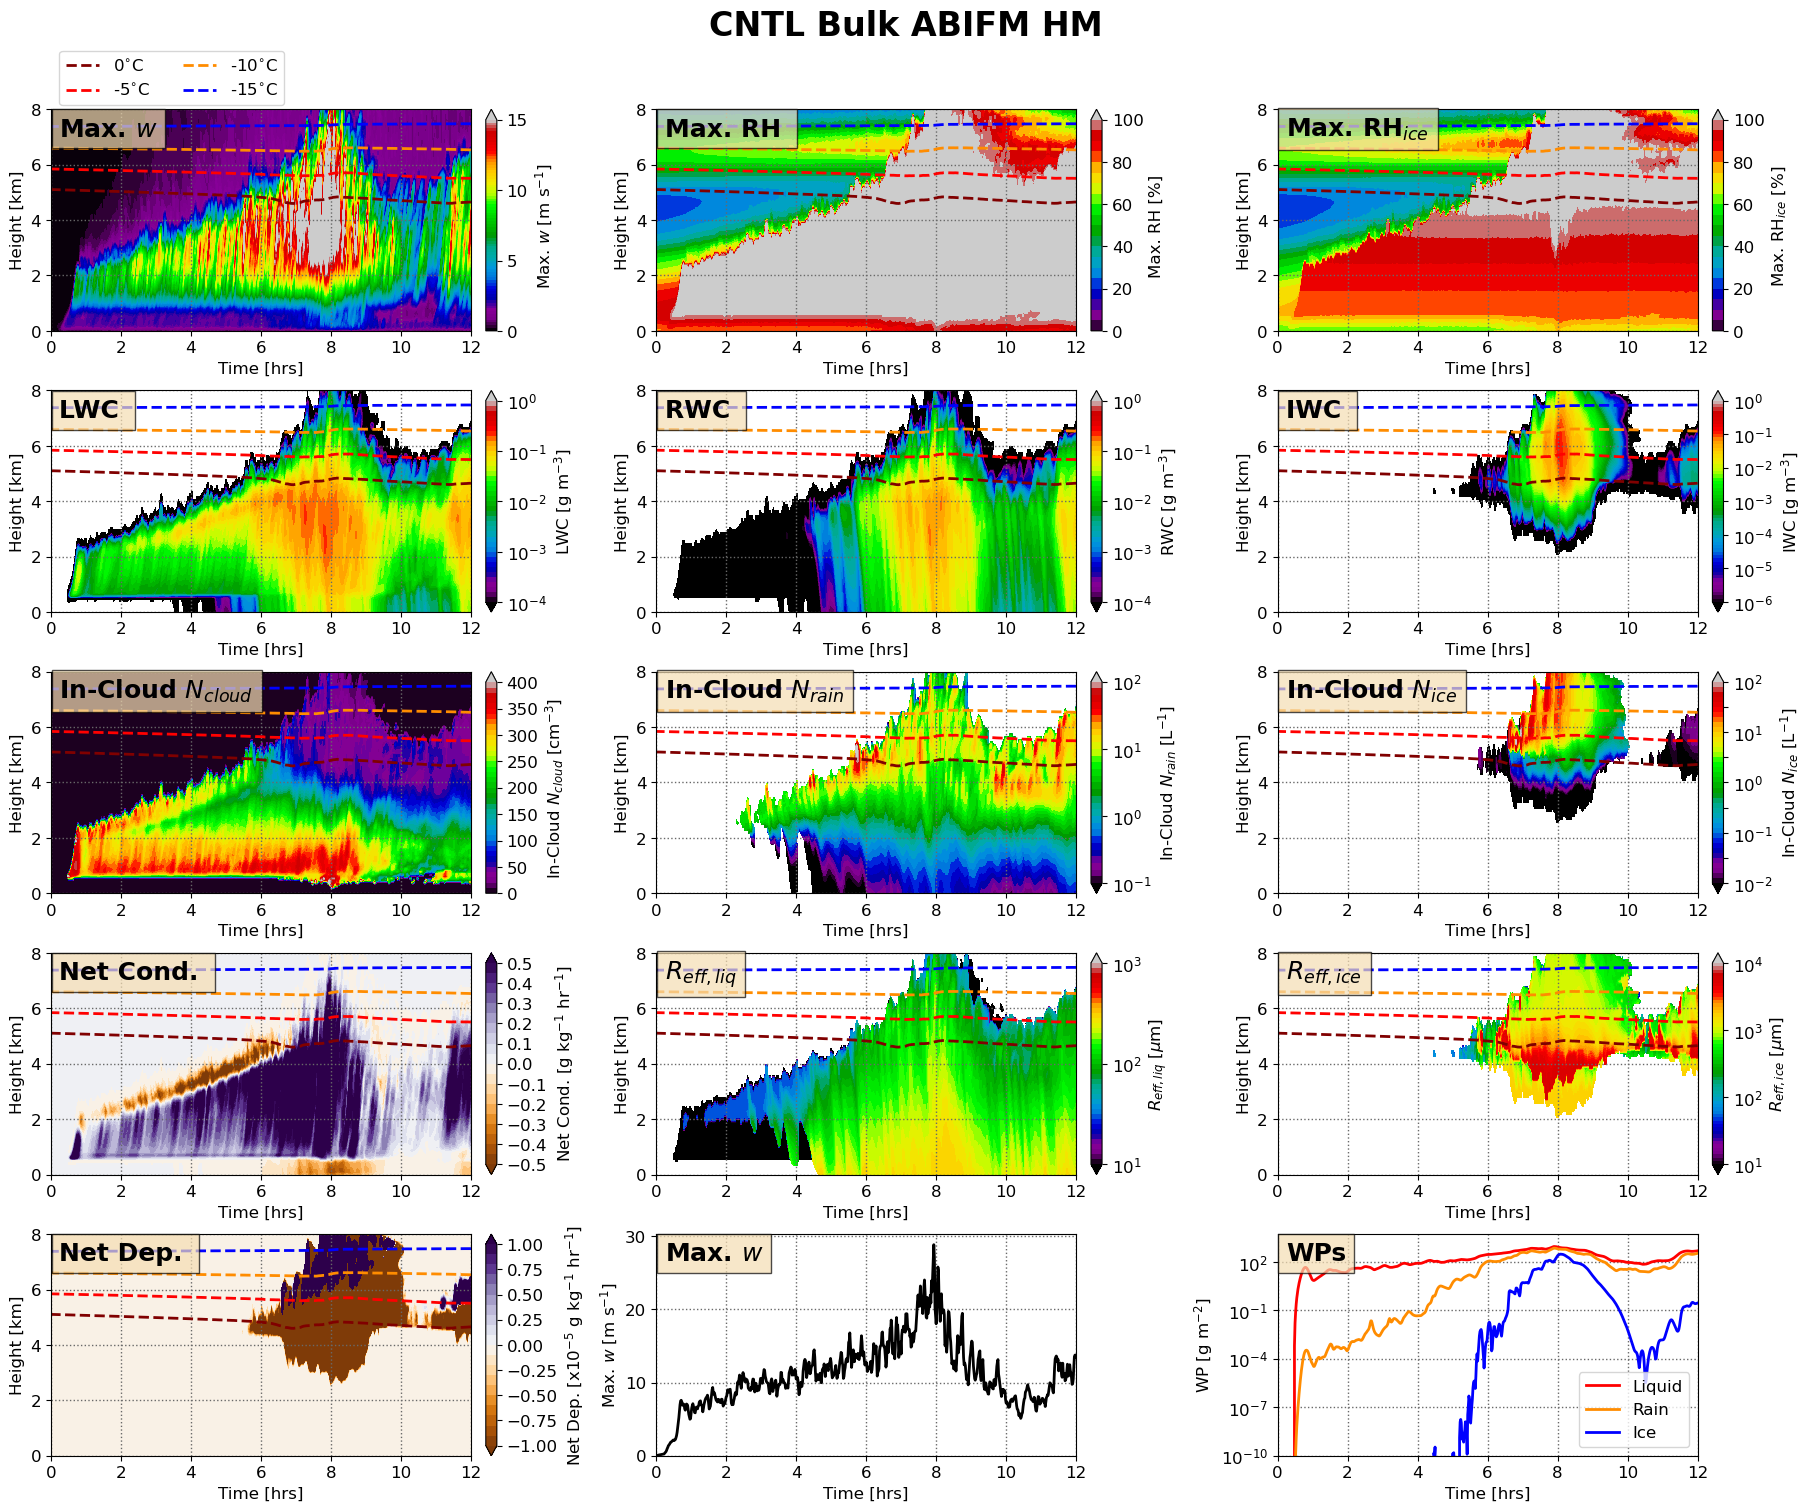

In [5]:
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
tmp_time = time
# --- Helper Functions ---
def setup_axes(axes, tmp_time, Fontsize):
    """Apply common formatting to all axes except last two."""
    for ax in axes[:-2]:
        ax.grid(ls='dotted', lw=1, c='dimgrey')
        ax.tick_params(labelsize=Fontsize)
        ax.set_ylabel('Height [km]', fontsize=Fontsize)
        ax.set_ylim(0, 8)
        ax.set_xlabel('Time [hrs]', fontsize=Fontsize)
        ax.set_xlim(4.5, np.max(tmp_time))
        #ax.set_xlim(np.min(tmp_time), np.max(tmp_time))

def plot_panel(ax, tmp_time, z, data, levels, cmap, label, Fontsize, norm=None, extend='both',ticks=None):
    """Generic contourf + colorbar + title box for each panel."""
    mappable = ax.contourf(tmp_time, z, data.T, levels=levels, cmap=cmap, norm=norm, extend=extend)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.01,ticks=ticks)
    cbar.ax.tick_params(labelsize=Fontsize)
    cbar.ax.set_ylabel(label, fontsize=Fontsize)
    ax.text(0.02, 0.88, label.split('[')[0], fontsize=Fontsize*1.5,
            fontweight='bold', c='k', transform=ax.transAxes,
            bbox=dict(boxstyle='square', facecolor='wheat', alpha=0.7))
    return mappable

# --- Data (replace with your actual arrays) ---
tmp_time = time / 3600.0  # hours
zw = out_dict['zw'] * 1.e-3
zt = out_dict['zt'] * 1.e-3
Fontsize = 12

# --- Create Figure & Axes ---
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 15), constrained_layout=True)
axes_flat = axes.ravel()

setup_axes(axes_flat, tmp_time, Fontsize)

dep_vmin=-1
dep_vmax=1
# --- Panels (define them in a loop-able dict) ---
panels = [
    dict(ax=axes_flat[0], data=wmax, z=zw, levels=np.arange(0, 15.2, 0.2),
         cmap='nipy_spectral', label='Max. $w$ [m s$^{-1}$]', extend='max',ticks=np.arange(0,20,5)),
    dict(ax=axes_flat[1], data=rhmax, z=zt, levels=np.arange(0, 105, 5),
         cmap='nipy_spectral', label='Max. RH [%]', extend='max',ticks=np.arange(0,120,20)),
    dict(ax=axes_flat[2], data=rhimax, z=zt, levels=np.arange(0, 105, 5),
         cmap='nipy_spectral', label='Max. RH$_{ice}$ [%]', extend='max',ticks=np.arange(0,120,20)),
    dict(ax=axes_flat[3], data=lwc, z=zt, levels=10.**np.arange(-4, 0.1, 0.1),
         cmap='nipy_spectral', label='LWC [g m$^{-3}$]',
         norm=matplotlib.colors.LogNorm(),ticks=10.**np.arange(-4,1,1)),
    dict(ax=axes_flat[4], data=rwc, z=zt, levels=10.**np.arange(-4, 0.1, 0.1),
         cmap='nipy_spectral', label='RWC [g m$^{-3}$]',
         norm=matplotlib.colors.LogNorm(),ticks=10.**np.arange(-4,1,1)),
    dict(ax=axes_flat[5], data=qi_iwc, z=zt, levels=10.**np.arange(-6, 0.1, 0.1),
         cmap='nipy_spectral', label='IWC [g m$^{-3}$]',
         norm=matplotlib.colors.LogNorm(),ticks=10.**np.arange(-6,1,1)),
    dict(ax=axes_flat[6], data=nc_cld, z=zt, levels=np.arange(0,410,10),
         cmap='nipy_spectral', label='In-Cloud $N_{cloud}$ [cm$^{-3}$]',extend='max',ticks=np.arange(0,450,50)),
    dict(ax=axes_flat[7], data=nr_cld*1.e3, z=zt,levels=10.**np.arange(-1,2.1,0.1),
         cmap='nipy_spectral', label='In-Cloud $N_{rain}$ [L$^{-1}$]',extend='both',norm=matplotlib.colors.LogNorm(),ticks=10.**np.arange(-1,3,1)),
    dict(ax=axes_flat[8], data=(nif_cld+nic_cld+nid_cld)/3.*1.e3, z=zt,levels=10.**np.arange(-2,2.1,0.1),
         cmap='nipy_spectral', label='In-Cloud $N_{ice}$ [L$^{-1}$]',extend='both',norm=matplotlib.colors.LogNorm(),ticks=10.**np.arange(-2,2.5,0.5)),
    dict(ax=axes_flat[9], data=net_cond, z=zt, levels=np.arange(-0.5, 0.55, 0.05),
         cmap='PuOr', label='Net Cond. [g kg$^{-1}$ hr$^{-1}$]',ticks=np.arange(-0.5,0.6,0.1)),
    dict(ax=axes_flat[10], data=0.5*(reff_cloud+reff_rain), z=zt,levels=10.**np.arange(1,3.05,0.05),
    #dict(ax=axes_flat[10], data=reff_cloud, z=zt,levels=np.arange(0,25.5,0.5),
         cmap='nipy_spectral', label='$R_{eff,liq}$ [$\\mu$m]',extend='both',norm=matplotlib.colors.LogNorm(),ticks=10.**np.arange(1,4,1)),
         #cmap='nipy_spectral', label='$R_{eff,cloud}$ [$\\mu$m]',extend='max',ticks=np.arange(0,30,5)),
    dict(ax=axes_flat[11], data=(reff_icef+reff_iced+reff_icec)/3., z=zt,levels=10.**np.arange(1,4.05,0.05),
         cmap='nipy_spectral', label='$R_{eff,ice}$ [$\\mu$m]',extend='both',norm=matplotlib.colors.LogNorm(),ticks=10.**np.arange(1,5,1)),
    dict(ax=axes_flat[12], data=net_dep*1.e5, z=zt, levels=np.linspace(-1,1,21),
         cmap='PuOr', label='Net Dep. [x10$^{-5}$ g kg$^{-1}$ hr$^{-1}$]',
         norm=matplotlib.colors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1),ticks=np.arange(-1,1.25,0.25)),
]

# --- Loop over panels ---
for p in panels:
    plot_panel(**p, tmp_time=tmp_time, Fontsize=Fontsize)

# --- Add Contour Temperature Lines with Legend ---
dumstr = '$^{\\circ}$C'
for ax in axes_flat[:-2]:
    ax.contour(tmp_time, zt, T.T-273.15, levels=[0], colors=['maroon'], linestyles=['dashed'], linewidths=[2])
    ax.contour(tmp_time, zt, T.T-273.15, levels=[-5], colors=['red'], linestyles=['dashed'], linewidths=[2])
    ax.contour(tmp_time, zt, T.T-273.15, levels=[-10], colors=['darkorange'], linestyles=['dashed'], linewidths=[2])
    ax.contour(tmp_time, zt, T.T-273.15, levels=[-15], colors=['blue'], linestyles=['dashed'], linewidths=[2])

legend_lines = [
    Line2D([0], [0], color='maroon', lw=2, ls='dashed'),
    Line2D([0], [0], color='red', lw=2, ls='dashed'),
    Line2D([0], [0], color='darkorange', lw=2, ls='dashed'),
    Line2D([0], [0], color='blue', lw=2, ls='dashed')
]
axes_flat[0].legend(legend_lines, ['0'+dumstr, '-5'+dumstr, '-10'+dumstr, '-15'+dumstr],
                    loc='upper left', bbox_to_anchor=(0., 1.3), fontsize=Fontsize,ncol=2)

#---------------------------
# Max W time series
#---------------------------
axes_flat[-2].set_xlabel('Time [hrs]',fontsize=Fontsize)
axes_flat[-2].tick_params(labelsize=Fontsize)
axes_flat[-2].grid(ls='dotted',lw=1,c='dimgrey')
axes_flat[-2].set_ylabel('Max. $w$ [m s$^{-1}$]',fontsize=Fontsize)
axes_flat[-2].plot(tmp_time,max_w,c='k',lw=2)
axes_flat[-2].text(0.02,0.88,'Max. $w$',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[-2].transAxes,bbox=props) 
axes_flat[-2].set_ylim(0)

#---------------------------
# WP
#---------------------------
axes_flat[-1].set_xlabel('Time [hrs]',fontsize=Fontsize)
axes_flat[-1].tick_params(labelsize=Fontsize)
axes_flat[-1].grid(ls='dotted',lw=1,c='dimgrey')
axes_flat[-1].set_ylabel('WP [g m$^{-2}$]',fontsize=Fontsize)
axes_flat[-1].plot(tmp_time,lwp,c='red',lw=2,label='Liquid')
axes_flat[-1].plot(tmp_time,rwp,c='darkorange',lw=2,label='Rain')
axes_flat[-1].plot(tmp_time,iwp,c='blue',lw=2,label='Ice')
axes_flat[-1].legend(fontsize=Fontsize,loc='best')
axes_flat[-1].set_yscale('log')
axes_flat[-1].set_ylim(1.e-10)
axes_flat[-1].text(0.02,0.88,'WPs',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[-1].transAxes,bbox=props) 

for ax in axes_flat:
    #ax.set_xlim(np.min(tmp_time),12)#np.max(tmp_time))
    ax.set_xlim(np.min(tmp_time),np.max(tmp_time))
    #ax.set_xlim(9,12)#np.max(tmp_time))


plt.suptitle(suptitle,fontsize=Fontsize*2.,fontweight='bold')

plt.show()


/tmp/ipykernel_2286449/2813826213.py:35: UserWarning: Log scale: values of z <= 0 have been masked
  iwc_plot = axes_flat[0].contourf(tmp_time,zt,qi_iwc.T,levels=iwc_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
/tmp/ipykernel_2286449/2813826213.py:50: UserWarning: Log scale: values of z <= 0 have been masked
  iwc_plot = axes_flat[1].contourf(tmp_time,zt,qif_iwc.T,levels=iwc_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
/tmp/ipykernel_2286449/2813826213.py:65: UserWarning: Log scale: values of z <= 0 have been masked
  iwc_plot = axes_flat[2].contourf(tmp_time,zt,qid_iwc.T,levels=iwc_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
/tmp/ipykernel_2286449/2813826213.py:79: UserWarning: Log scale: values of z <= 0 have been masked
  iwc_plot = axes_flat[3].contourf(tmp_time,zt,qic_iwc.T,levels=iwc_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
/tmp/ipykernel_2286449/2813826213.py:

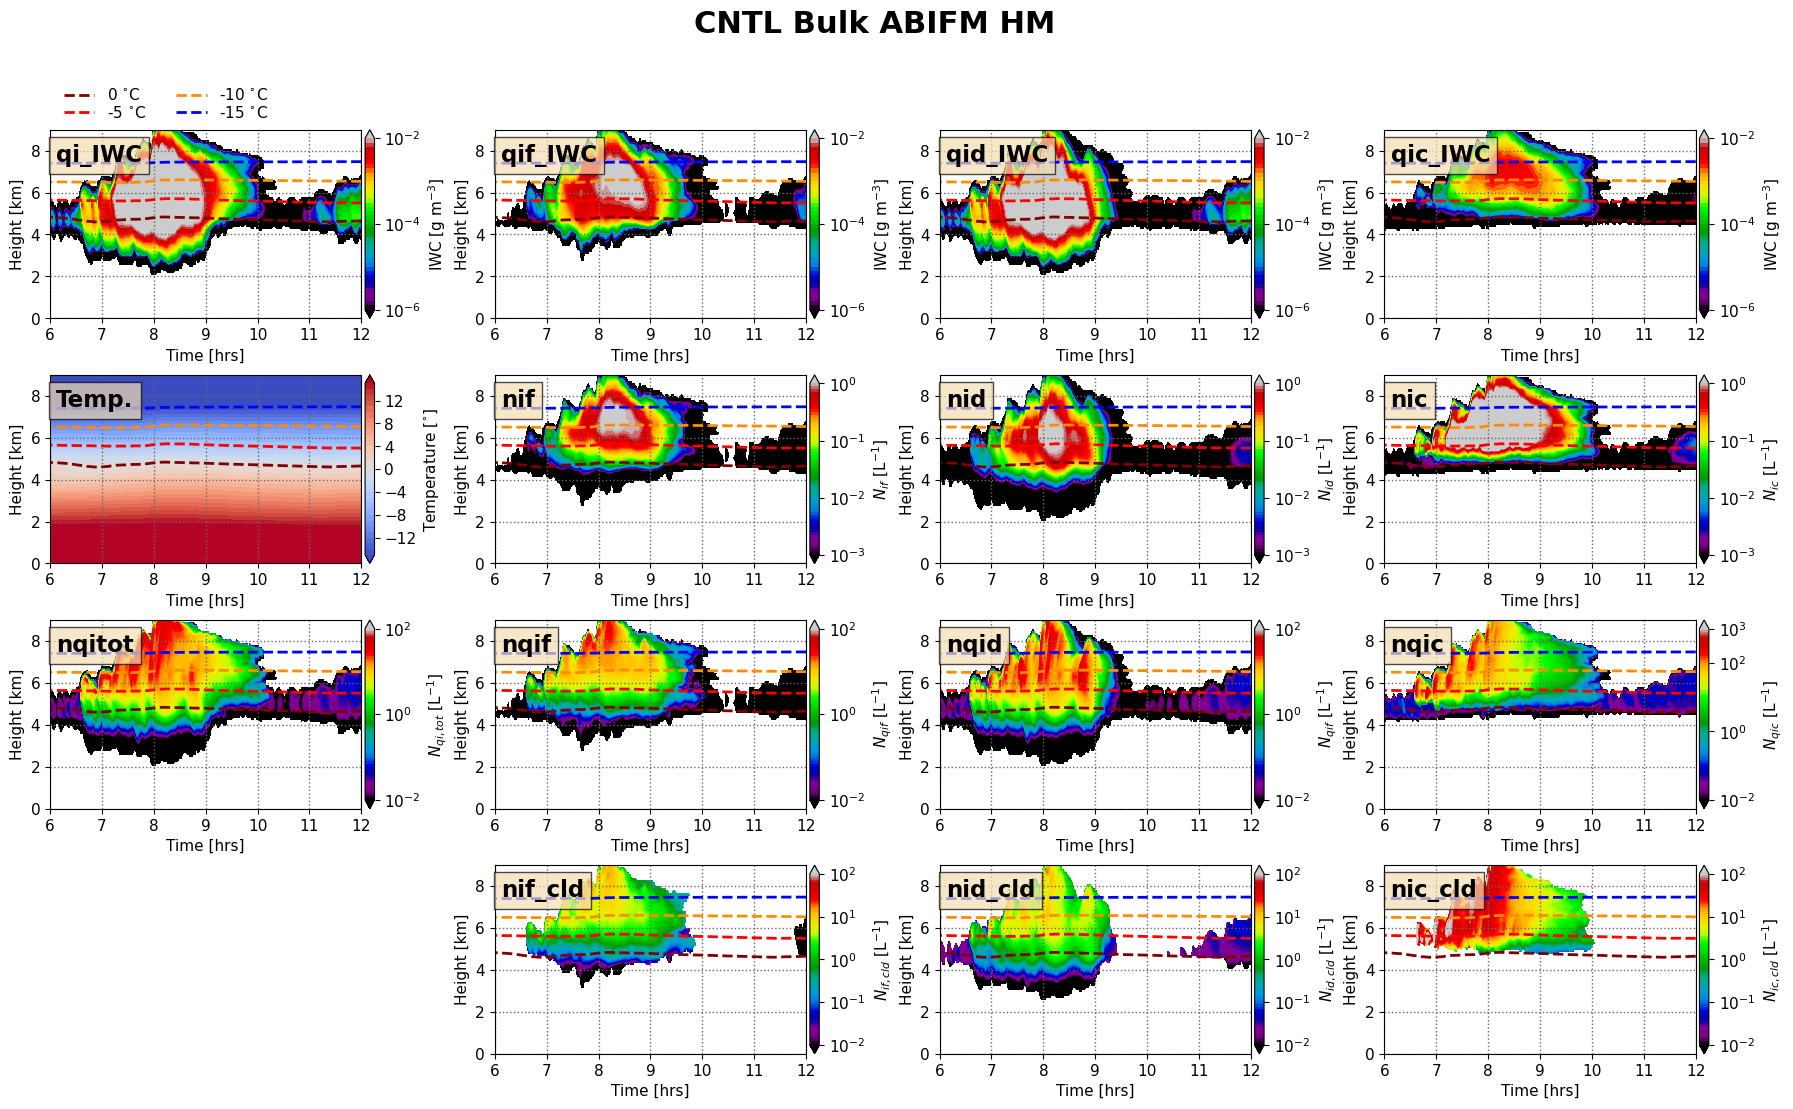

In [6]:
#=======================================
# Ice Only
#=======================================
minx = 0
maxx = 12

fig,axes = plt.subplots(nrows=4,ncols=4,figsize=(22,12))
axes_flat = np.ndarray.flatten(axes)



tmp_time = time/60./60.
zw = out_dict['zw']*1.e-3
zt = out_dict['zt']*1.e-3

Fontsize=11
custom_lines = [matplotlib.lines.Line2D([0],[0],lw=2,c='maroon',ls='dashed',label='0 $^{\\circ}$C'),\
            matplotlib.lines.Line2D([0],[0],lw=2,c='red',ls='dashed',label='-5 $^{\\circ}$C'),\
            matplotlib.lines.Line2D([0],[0],lw=2,c='darkorange',ls='dashed',label='-10 $^{\\circ}$C'),\
            matplotlib.lines.Line2D([0],[0],lw=2,c='blue',ls='dashed',label='-15 $^{\\circ}$C'),\
               ]
for ax in axes_flat:
    ax.grid(ls='dotted',lw=1,c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_ylabel('Height [km]',fontsize=Fontsize)
    ax.set_ylim(0,9)
    ax.set_xlabel('Time [hrs]',fontsize=Fontsize)

#axes_flat[0].legend(loc='lower left',fontsize=Fontsize*0.75)
    
#---------------------------
# qi_IWC
#---------------------------
iwc_levs = 10.**np.arange(-6,-1.9,0.1)
iwc_plot = axes_flat[0].contourf(tmp_time,zt,qi_iwc.T,levels=iwc_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-6,1.e-4,1.e-2]
iwc_cbar = fig.colorbar(iwc_plot,pad=0.01,ticks=dum_ticks)
iwc_cbar.ax.tick_params(labelsize=Fontsize)
iwc_cbar.ax.set_ylabel('IWC [g m$^{-3}$]',fontsize=Fontsize) 
dumlist = ['10$^{-6}$','10$^{-4}$','10$^{-2}$']
iwc_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[0].text(0.02,0.83,'qi_IWC',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[0].transAxes,bbox=props) 


#---------------------------
# qif_IWC
#---------------------------
iwc_levs = 10.**np.arange(-6,-1.9,0.1)
iwc_plot = axes_flat[1].contourf(tmp_time,zt,qif_iwc.T,levels=iwc_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-6,1.e-4,1.e-2]
iwc_cbar = fig.colorbar(iwc_plot,pad=0.01,ticks=dum_ticks)
iwc_cbar.ax.tick_params(labelsize=Fontsize)
iwc_cbar.ax.set_ylabel('IWC [g m$^{-3}$]',fontsize=Fontsize) 
dumlist = ['10$^{-6}$','10$^{-4}$','10$^{-2}$']
iwc_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[1].text(0.02,0.83,'qif_IWC',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[1].transAxes,bbox=props)


#---------------------------
# qid_IWC
#---------------------------
iwc_levs = 10.**np.arange(-6,-1.9,0.1)
iwc_plot = axes_flat[2].contourf(tmp_time,zt,qid_iwc.T,levels=iwc_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-6,1.e-4,1.e-2]
iwc_cbar = fig.colorbar(iwc_plot,pad=0.01,ticks=dum_ticks)
iwc_cbar.ax.tick_params(labelsize=Fontsize)
iwc_cbar.ax.set_ylabel('IWC [g m$^{-3}$]',fontsize=Fontsize) 
dumlist = ['10$^{-6}$','10$^{-4}$','10$^{-2}$']
iwc_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[2].text(0.02,0.83,'qid_IWC',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[2].transAxes,bbox=props)

#---------------------------
# qic_IWC
#---------------------------
iwc_levs = 10.**np.arange(-6,-1.9,0.1)
iwc_plot = axes_flat[3].contourf(tmp_time,zt,qic_iwc.T,levels=iwc_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-6,1.e-4,1.e-2]
iwc_cbar = fig.colorbar(iwc_plot,pad=0.01,ticks=dum_ticks)
iwc_cbar.ax.tick_params(labelsize=Fontsize)
iwc_cbar.ax.set_ylabel('IWC [g m$^{-3}$]',fontsize=Fontsize) 
dumlist = ['10$^{-6}$','10$^{-4}$','10$^{-2}$']
iwc_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[3].text(0.02,0.83,'qic_IWC',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[3].transAxes,bbox=props)

#---------------------------
# nif
#---------------------------
nif_levs = 10.**np.arange(-3,0.05,0.05)
nif_plot = axes_flat[5].contourf(tmp_time,zt,nif.T*1.e3,levels=nif_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-3,1.e-2,1.e-1,1.e0]
nif_cbar = fig.colorbar(nif_plot,pad=0.01,ticks=dum_ticks)
nif_cbar.ax.tick_params(labelsize=Fontsize)
nif_cbar.ax.set_ylabel('$N_{if}$ [L$^{-1}$]',fontsize=Fontsize) 
dumlist = ['10$^{-3}$','10$^{-2}$','10$^{-1}$','10$^{0}$']
nif_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[5].text(0.02,0.83,'nif',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[5].transAxes,bbox=props)

#---------------------------
# nid
#---------------------------
nid_levs = 10.**np.arange(-3,0.05,0.05)
nid_plot = axes_flat[6].contourf(tmp_time,zt,nid.T*1.e3,levels=nid_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-3,1.e-2,1.e-1,1.e0]
nid_cbar = fig.colorbar(nid_plot,pad=0.01,ticks=dum_ticks)
nid_cbar.ax.tick_params(labelsize=Fontsize)
nid_cbar.ax.set_ylabel('$N_{id}$ [L$^{-1}$]',fontsize=Fontsize) 
dumlist = ['10$^{-3}$','10$^{-2}$','10$^{-1}$','10$^{0}$']
nid_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[6].text(0.02,0.83,'nid',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[6].transAxes,bbox=props)

#---------------------------
# nic
#---------------------------
nic_levs = 10.**np.arange(-3,0.05,0.05)
nic_plot = axes_flat[7].contourf(tmp_time,zt,nic.T*1.e3,levels=nic_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-3,1.e-2,1.e-1,1.e0]
nic_cbar = fig.colorbar(nic_plot,pad=0.01,ticks=dum_ticks)
nic_cbar.ax.tick_params(labelsize=Fontsize)
nic_cbar.ax.set_ylabel('$N_{ic}$ [L$^{-1}$]',fontsize=Fontsize) 
dumlist = ['10$^{-3}$','10$^{-2}$','10$^{-1}$','10$^{0}$']
nic_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[7].text(0.02,0.83,'nic',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[7].transAxes,bbox=props)

#---------------------------
# nqif
#---------------------------
nqif_levs = 10.**np.arange(-2,2.05,0.05)
nqif_plot = axes_flat[9].contourf(tmp_time,zt,nqif.T*1.e3,levels=nqif_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-2,1.e0,1.e2]
nqif_cbar = fig.colorbar(nqif_plot,pad=0.01,ticks=dum_ticks)
nqif_cbar.ax.tick_params(labelsize=Fontsize)
nqif_cbar.ax.set_ylabel('$N_{qif}$ [L$^{-1}$]',fontsize=Fontsize) 
dumlist = ['10$^{-2}$','10$^{0}$','10$^{2}$']
nqif_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[9].text(0.02,0.83,'nqif',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[9].transAxes,bbox=props)

#---------------------------
# nqid
#---------------------------
nqid_levs = 10.**np.arange(-2,2.05,0.05)
nqid_plot = axes_flat[10].contourf(tmp_time,zt,nqid.T*1.e3,levels=nqid_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-2,1.e0,1.e2]
nqid_cbar = fig.colorbar(nqid_plot,pad=0.01,ticks=dum_ticks)
nqid_cbar.ax.tick_params(labelsize=Fontsize)
nqid_cbar.ax.set_ylabel('$N_{qif}$ [L$^{-1}$]',fontsize=Fontsize) 
dumlist = ['10$^{-2}$','10$^{0}$','10$^{2}$']
nqid_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[10].text(0.02,0.83,'nqid',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[10].transAxes,bbox=props)
    
#---------------------------
# nqic
#---------------------------
nqic_levs = 10.**np.arange(-2,3.05,0.05)
nqic_plot = axes_flat[11].contourf(tmp_time,zt,nqic.T*1.e3,levels=nqic_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-2,1.e0,1.e2,1.e3]
nqic_cbar = fig.colorbar(nqic_plot,pad=0.01,ticks=dum_ticks)
nqic_cbar.ax.tick_params(labelsize=Fontsize)
nqic_cbar.ax.set_ylabel('$N_{qic}$ [L$^{-1}$]',fontsize=Fontsize) 
dumlist = ['10$^{-2}$','10$^{0}$','10$^{2}$','10$^{3}$']
nqic_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[11].text(0.02,0.83,'nqic',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[11].transAxes,bbox=props)
    
#---------------------------
# nif_cld
#---------------------------
nif_cld_levs = 10.**np.arange(-2,2.05,0.05)
nif_cld_plot = axes_flat[13].contourf(tmp_time,zt,nif_cld.T*1.e3,levels=nif_cld_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-2,1.e-1,1.e0,1.e1,1.e2]
nif_cld_cbar = fig.colorbar(nif_cld_plot,pad=0.01,ticks=dum_ticks)
nif_cld_cbar.ax.tick_params(labelsize=Fontsize)
nif_cld_cbar.ax.set_ylabel('$N_{if,cld}$ [L$^{-1}$]',fontsize=Fontsize) 
dumlist = ['10$^{-2}$','10$^{-1}$','10$^{0}$','10$^{1}$','10$^{2}$']
nif_cld_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[13].text(0.02,0.83,'nif_cld',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[13].transAxes,bbox=props) 


#---------------------------
# nid_cld
#---------------------------
nid_cld_levs = 10.**np.arange(-2,2.05,0.05)
nid_cld_plot = axes_flat[14].contourf(tmp_time,zt,nid_cld.T*1.e3,levels=nid_cld_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-2,1.e-1,1.e0,1.e1,1.e2]
nid_cld_cbar = fig.colorbar(nid_cld_plot,pad=0.01,ticks=dum_ticks)
nid_cld_cbar.ax.tick_params(labelsize=Fontsize)
nid_cld_cbar.ax.set_ylabel('$N_{id,cld}$ [L$^{-1}$]',fontsize=Fontsize) 
dumlist = ['10$^{-2}$','10$^{-1}$','10$^{0}$','10$^{1}$','10$^{2}$']
nid_cld_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[14].text(0.02,0.83,'nid_cld',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[14].transAxes,bbox=props)


#---------------------------
# nic_cld
#---------------------------
nic_cld_levs = 10.**np.arange(-2,2.05,0.05)
nic_cld_plot = axes_flat[15].contourf(tmp_time,zt,nic_cld.T*1.e3,levels=nic_cld_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-2,1.e-1,1.e0,1.e1,1.e2]
nic_cld_cbar = fig.colorbar(nic_cld_plot,pad=0.01,ticks=dum_ticks)
nic_cld_cbar.ax.tick_params(labelsize=Fontsize)
nic_cld_cbar.ax.set_ylabel('$N_{ic,cld}$ [L$^{-1}$]',fontsize=Fontsize) 
dumlist = ['10$^{-2}$','10$^{-1}$','10$^{0}$','10$^{1}$','10$^{2}$']
nic_cld_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[15].text(0.02,0.83,'nic_cld',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[15].transAxes,bbox=props)

#---------------------------
# Temperature
#---------------------------
T_levs = np.arange(-15,16,1)
T_plot = axes_flat[4].contourf(tmp_time,zt,T.T-273.15,levels=T_levs,cmap='coolwarm',extend='both')
#dum_ticks = np.arange(0,12,2)
T_cbar = fig.colorbar(T_plot,pad=0.01)#,ticks=dum_ticks)
T_cbar.ax.tick_params(labelsize=Fontsize)
T_cbar.ax.set_ylabel('Temperature [$^{\\circ}$]',fontsize=Fontsize)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[4].text(0.02,0.83,'Temp.',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[4].transAxes,bbox=props)   


#---------------------------
# nqitot
#---------------------------
nqitot_levs = 10.**np.arange(-2,2.05,0.05)
nqitot_plot = axes_flat[8].contourf(tmp_time,zt,nqitot.T*1.e3,levels=nqitot_levs,cmap='nipy_spectral',norm=matplotlib.colors.LogNorm(),extend='both')
dum_ticks = [1.e-2,1.e0,1.e2]
nqitot_cbar = fig.colorbar(nqitot_plot,pad=0.01,ticks=dum_ticks)
nqitot_cbar.ax.tick_params(labelsize=Fontsize)
nqitot_cbar.ax.set_ylabel('$N_{qi,tot}$ [L$^{-1}$]',fontsize=Fontsize) 
dumlist = ['10$^{-2}$','10$^{0}$','10$^{2}$']
nqitot_cbar.ax.set_yticklabels(dumlist)
props = dict(boxstyle='square', facecolor='wheat', alpha=0.7)
axes_flat[8].text(0.02,0.83,'nqitot',fontsize=Fontsize*1.5,fontweight='bold',c='k',transform=axes_flat[8].transAxes,bbox=props)

#fig.delaxes(axes_flat[8])
fig.delaxes(axes_flat[12])

for ax in axes_flat:
    ax.contour(tmp_time,zt,T.T-273.15,levels=[0],colors=['maroon'],linestyles=['dashed'],linewidths=[2])
    ax.contour(tmp_time,zt,T.T-273.15,levels=[-5],colors=['red'],linestyles=['dashed'],linewidths=[2])
    ax.contour(tmp_time,zt,T.T-273.15,levels=[-10],colors=['darkorange'],linestyles=['dashed'],linewidths=[2])
    ax.contour(tmp_time,zt,T.T-273.15,levels=[-15],colors=['blue'],linestyles=['dashed'],linewidths=[2])
axes_flat[0].legend(handles=custom_lines,fontsize=Fontsize,loc='upper left',framealpha=False,ncol=2,labelspacing=0.1,bbox_to_anchor=(0,1.3))   

for ax in axes_flat:
    #ax.set_xlim(np.min(tmp_time),np.max(tmp_time))
    ax.set_xlim(6,np.max(tmp_time))
    #ax.set_xlim(9,12)

plt.suptitle(suptitle,fontsize=Fontsize*2.,fontweight='bold')
plt.subplots_adjust(hspace=0.3,wspace=0.2)
plt.show()
plt.close()    

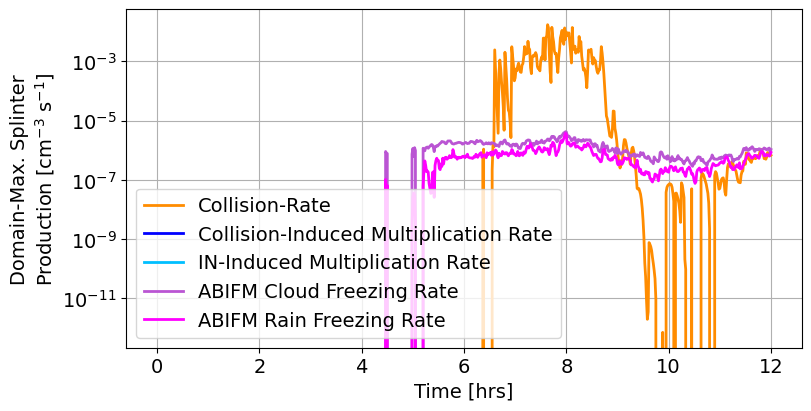

In [7]:
fig = plt.figure(figsize=(8,4),constrained_layout=True)
ax1 = fig.add_subplot(111)
axlist = [ax1]
Fontsize=14
for ax in axlist:
    ax.set_xlabel('Time [hrs]',fontsize=Fontsize)
    ax.set_ylabel('Domain-Max. Splinter\nProduction [cm$^{-3}$ s$^{-1}$]',fontsize=Fontsize)
    ax.tick_params(labelsize=Fontsize)
    ax.grid()

ax1.plot(out_dict['time']/3600.,out_dict['max_sh_coag_raw'],lw=2,c='darkorange',label='Collision-Rate')
ax1.plot(out_dict['time']/3600.,out_dict['max_sh_coag'],lw=2,c='blue',label='Collision-Induced Multiplication Rate')
ax1.plot(out_dict['time']/3600.,out_dict['max_sh_in_r'],lw=2,c='deepskyblue',label='IN-Induced Multiplication Rate')
ax1.plot(out_dict['time']/3600.,out_dict['max_in_imm_c'],lw=2,c='mediumorchid',label='ABIFM Cloud Freezing Rate')
ax1.plot(out_dict['time']/3600.,out_dict['max_in_imm_r'],lw=2,c='magenta',label='ABIFM Rain Freezing Rate')

ax1.legend(loc='lower left',fontsize=Fontsize)
ax1.set_yscale('log')
plt.show()
plt.close()